In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('01-2025.csv')

In [5]:
df.head()

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,67946352563,2025-01-01 09:01,Outbound,00:00:19,NaN,Sam Steindorf
1,67940463378,2025-01-01 09:01,Outbound,00:00:12,NaN,Sam Steindorf
2,67925186740,2025-01-01 09:02,Inbound,00:18:35,NaN,Sam Steindorf
3,67918009174,2025-01-01 11:00,Outbound,00:03:26,NaN,Sam Steindorf
4,67942371879,2025-01-01 11:03,NaN,00:07:57,NaN,Garrett Evans


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10996 entries, 0 to 10995
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Record ID             10996 non-null  int64  
 1   Activity date         10996 non-null  str    
 2   Call direction        9858 non-null   str    
 3   Call duration         10204 non-null  str    
 4   hs_call_outcome       0 non-null      float64
 5   Activity assigned to  10576 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 972.0 KB


In [11]:
df1 = df.drop(columns=['hs_call_outcome', 'Record ID'])

In [15]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 10996 entries, 0 to 10995
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Activity date         10996 non-null  str  
 1   Call direction        9858 non-null   str  
 2   Call duration         10204 non-null  str  
 3   Activity assigned to  10576 non-null  str  
dtypes: str(4)
memory usage: 800.2 KB


In [17]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format="%Y-%m-%d %H:%M",
    errors = 'coerce'
)

In [19]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 10996 entries, 0 to 10995
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         10996 non-null  datetime64[us]
 1   Call direction        9858 non-null   str           
 2   Call duration         10204 non-null  str           
 3   Activity assigned to  10576 non-null  str           
dtypes: datetime64[us](1), str(3)
memory usage: 628.4 KB


# Call Count per day

In [22]:
df2 = df1.copy()

In [24]:
df2['date'] = df2['Activity date'].dt.date

In [26]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2025-01-01 09:01:00,Outbound,00:00:19,Sam Steindorf,2025-01-01
1,2025-01-01 09:01:00,Outbound,00:00:12,Sam Steindorf,2025-01-01
2,2025-01-01 09:02:00,Inbound,00:18:35,Sam Steindorf,2025-01-01
3,2025-01-01 11:00:00,Outbound,00:03:26,Sam Steindorf,2025-01-01
4,2025-01-01 11:03:00,NaN,00:07:57,Garrett Evans,2025-01-01


In [34]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name = 'call_count')
    .rename(columns={'Activity date': 'date'})
)

In [36]:
daily_calls.head()

,date,call_count
0,2025-01-01,47
1,2025-01-02,511
2,2025-01-03,340
3,2025-01-04,118
4,2025-01-05,89


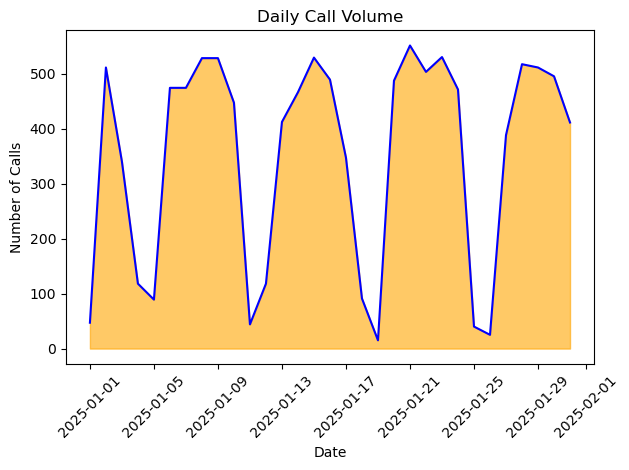

In [38]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'], color='blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color='orange', alpha=0.6)

plt.title('Daily Call Volume')
plt.xlabel('Date')
plt.ylabel('Number of Calls')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Count of Call in Weekdays

In [41]:
df1['day'] = df1['Activity date'].dt.day_name()

In [43]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2025-01-01 09:01:00,Outbound,00:00:19,Sam Steindorf,Wednesday
1,2025-01-01 09:01:00,Outbound,00:00:12,Sam Steindorf,Wednesday
2,2025-01-01 09:02:00,Inbound,00:18:35,Sam Steindorf,Wednesday
3,2025-01-01 11:00:00,Outbound,00:03:26,Sam Steindorf,Wednesday
4,2025-01-01 11:03:00,NaN,00:07:57,Garrett Evans,Wednesday


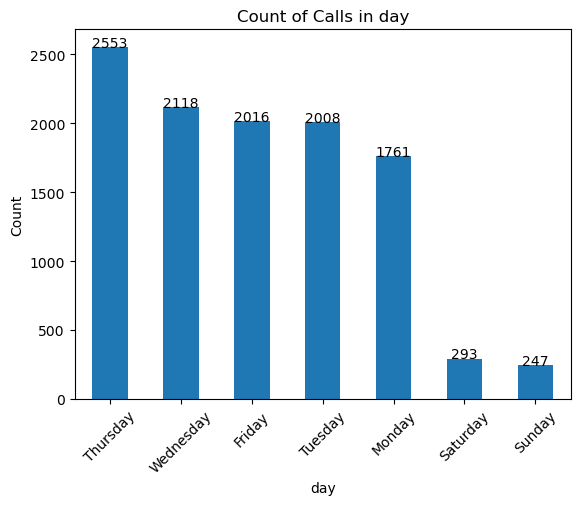

In [45]:
day_Counts = df1['day'].value_counts()
day_Counts.plot(kind='bar')
ax = day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i, v+1, str(v), ha = 'center')

plt.title('Count of Calls in day')
plt.xlabel('day')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

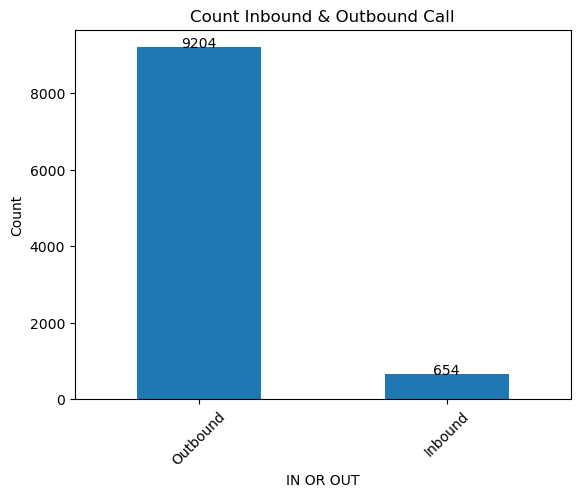

In [48]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i, v+1, str(v), ha='center')

plt.title('Count Inbound & Outbound Call')
plt.xlabel('IN OR OUT')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [51]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

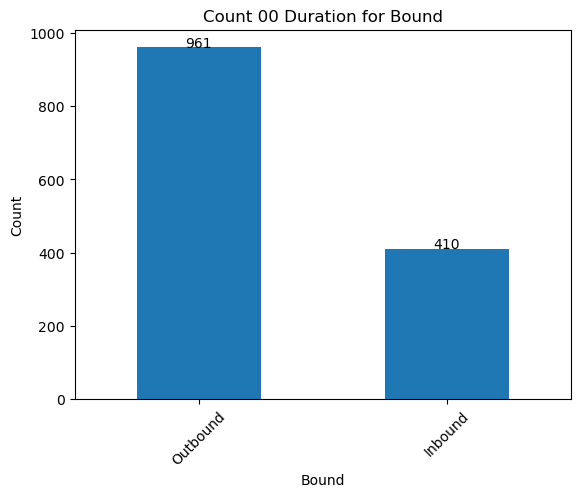

In [53]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind='bar')
ax = N_B_Counts.plot(kind='bar')

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha= 'center')

plt.title("Count 00 Duration for Bound")
plt.xlabel('Bound')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Call duration NULL but have Call direction

In [56]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
2198,2025-01-08 14:00:00,Outbound,NaN,Chrystel Manabat,Wednesday
4808,2025-01-15 15:36:00,Outbound,NaN,Keith Antonio,Wednesday
5619,2025-01-17 09:25:00,Inbound,NaN,Robin Stoehr,Friday
6597,2025-01-21 11:00:00,Outbound,NaN,Chrystel Manabat,Tuesday
6665,2025-01-21 12:18:00,Outbound,NaN,Keith Antonio,Tuesday
9064,2025-01-28 08:43:00,Inbound,NaN,Robin Stoehr,Tuesday
9910,2025-01-29 17:21:00,Inbound,NaN,Christian Banks,Wednesday
10599,2025-01-31 09:43:00,Inbound,NaN,Robin Stoehr,Friday


In [58]:
df4 = df1.copy()

In [60]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors='coerce')
    .dt.total_seconds()/60
)

In [62]:
(df4['Call duration'] == 0).sum()

1371

In [64]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 10996 entries, 0 to 10995
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         10996 non-null  datetime64[us]
 1   Call direction        9858 non-null   str           
 2   Call duration         10204 non-null  float64       
 3   Activity assigned to  10576 non-null  str           
 4   day                   10996 non-null  str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 711.4 KB


In [66]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [68]:
df4 = df4.dropna(subset = ['Call direction'])

In [70]:
(df4['Call duration'] == 0).sum()

1379

In [72]:
df4.info()

<class 'pandas.DataFrame'>
Index: 9858 entries, 0 to 10995
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         9858 non-null   datetime64[us]
 1   Call direction        9858 non-null   str           
 2   Call duration         9858 non-null   float64       
 3   Activity assigned to  9449 non-null   str           
 4   day                   9858 non-null   str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 722.6 KB


# Working Call Assigner

In [75]:
df1['Activity assigned to'].nunique()

22

In [77]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[    'Sam Steindorf',     'Garrett Evans',   'Spenser Szakacs',
                 nan,     'Oliver Martin',       'Tyler Smith',
    'Boston Hoppman',      'David Valdez',      'Robin Stoehr',
     'Keith Antonio',    'Cameron Dudley',       'Paol Guzman',
         'Terry Kim',        'Tyler Jury',    'David Banister',
      'Karen Parker', 'Brittany Digiulio',         'Juan Calo',
  'Chrystel Manabat',   'Adonis Baybayan',    'Nick Rothacher',
      'Bill Goodwin',   'Christian Banks']
Length: 23, dtype: str

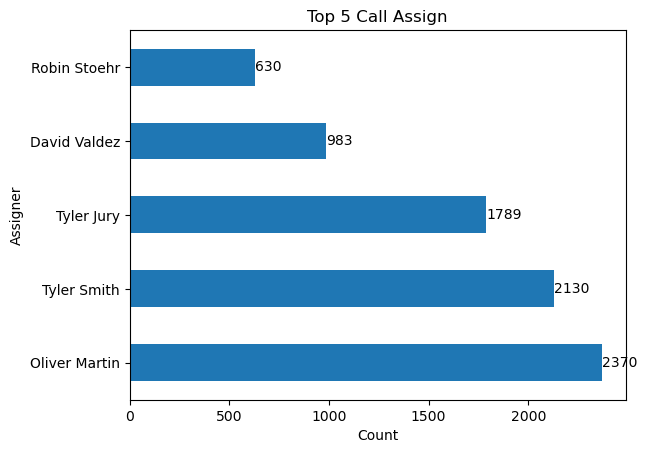

In [81]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va='center')

plt.title('Top 5 Call Assign')
plt.xlabel('Count')
plt.ylabel("Assigner")
plt.show()

# Max Call Duration

In [84]:
df4['Call duration'].max()

146.18333333333334

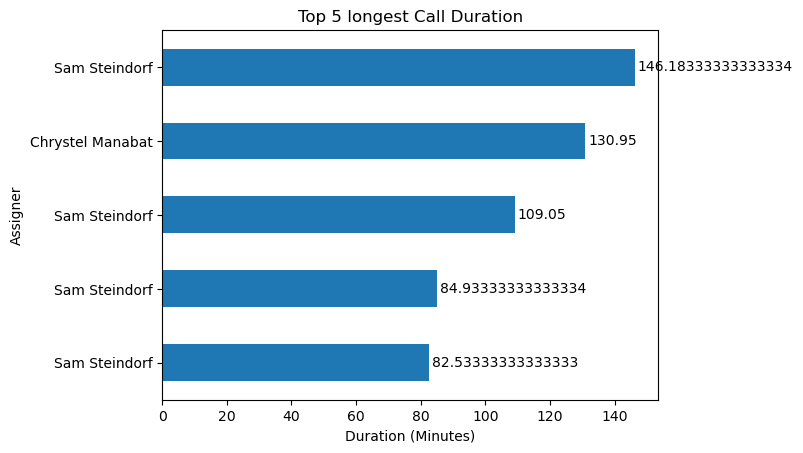

In [86]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind='barh')

for i,v in enumerate(top5['Call duration'].sort_values()):
    ax.text(v+1, i, str(v), va= 'center')

plt.title('Top 5 longest Call Duration')
plt.xlabel("Duration (Minutes)")
plt.ylabel('Assigner')
plt.show()

# Only Weekdays Call Volume

In [89]:
df3 = df1.copy()

In [91]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [93]:
df3['day'].unique()

<ArrowStringArray>
['Wednesday', 'Thursday', 'Friday', 'Monday', 'Tuesday']
Length: 5, dtype: str

In [95]:
week_day_calls = (
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

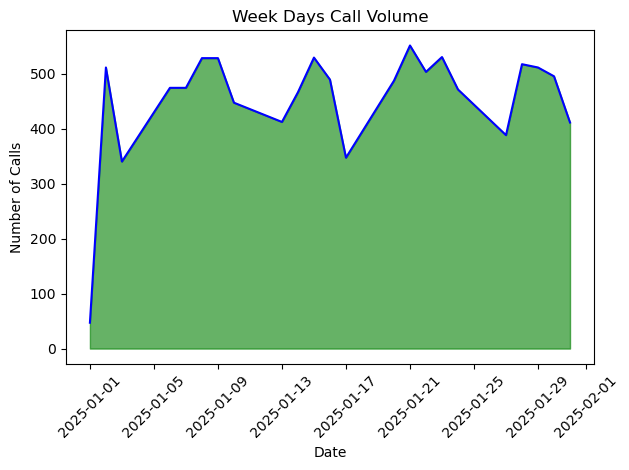

In [99]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'], color='green', alpha=0.6)

plt.title('Week Days Call Volume')
plt.xlabel('Date')
plt.ylabel('Number of Calls')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [102]:
df5 = df4.copy()

In [104]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [106]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
898,2025-01-04 03:28:00,Inbound,0.000000,NaN,Saturday
900,2025-01-04 10:10:00,Outbound,0.116667,David Valdez,Saturday
901,2025-01-04 10:11:00,Outbound,0.066667,David Valdez,Saturday
902,2025-01-04 10:24:00,Outbound,0.033333,David Valdez,Saturday
903,2025-01-04 11:01:00,Outbound,7.066667,Sam Steindorf,Saturday


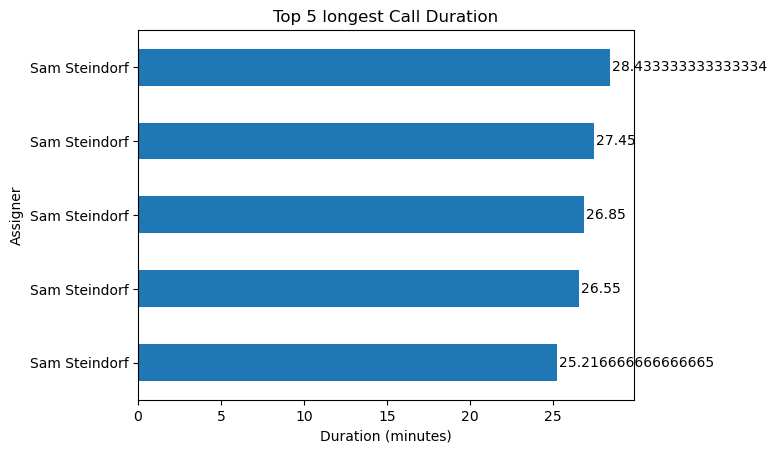

In [110]:
top5 = df5.nlargest(5, 'Call duration')

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind='barh')

for i,v in enumerate(top5['Call duration'].sort_values()):
    ax.text(v +0.1,i,str(v), va='center')

plt.title('Top 5 longest Call Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Assigner')
plt.show()

# Top5 WEEKEND CALL ASSIGNER

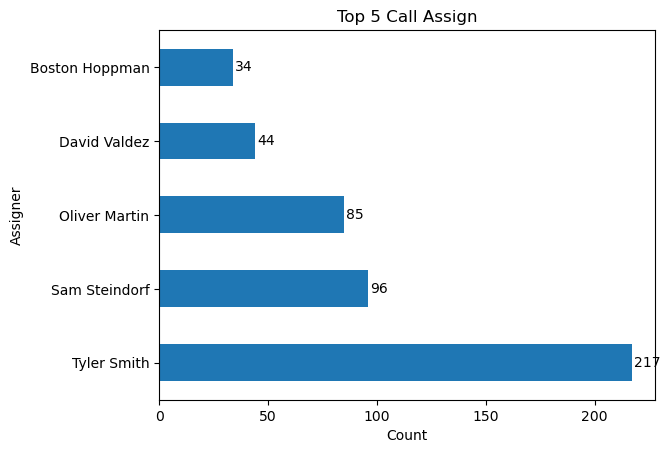

In [113]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1,i,str(v), va='center')

plt.title('Top 5 Call Assign')
plt.xlabel('Count')
plt.ylabel('Assigner')
plt.show()

# Average Call Duration

In [116]:
df4['Call duration'].mean()

2.055684046797863

In [118]:
df4['Call duration'].median()

0.11666666666666667

# Without Call Assigner Calls

In [121]:
df6 = df3.copy()

In [123]:
df6['month'] = df6['Activity date'].dt.month_name()

In [125]:
no_assigner_calls = df6[df6['Activity assigned to'].isna()]

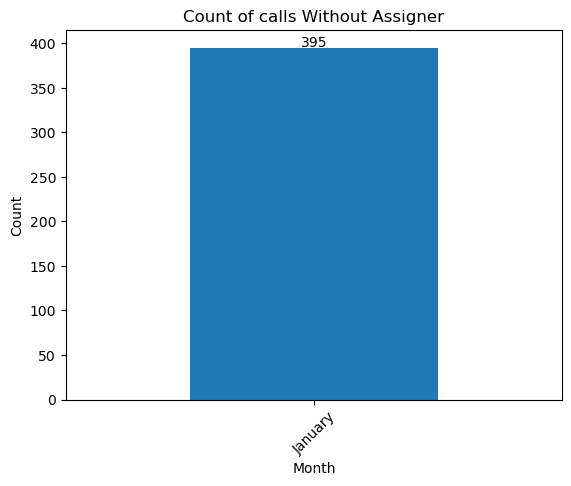

In [137]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Top5 Peak Call Date

In [140]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [142]:
top5 = daily_calls.sort_values(ascending=False).head(5)

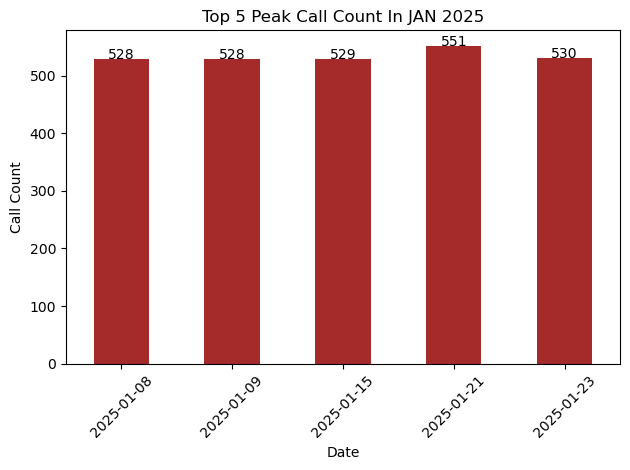

In [146]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count In JAN 2025")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()